### paired scRNA + scATAC metrics plot

In [1]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib.colors import LinearSegmentedColormap
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.formatters import tickcross
from plottable.plots import bar

In [2]:
## define functions
def plot_simple_metrics_table(df,
                              model_col,
                              model_col_width,
                              group_col,
                              metric_cols,
                              metric_col_weights,
                              metric_col_titles=None,
                              metric_col_width=1.5,
                              aggregate_col_width=1.5,
                              plot_width=15,
                              plot_height=10,
                              group_label_dict={"seqfish_mouse_organogenesis_embryo2": "seqFISH \n Mouse Organogenesis"},
                              overall_score_col="Overall Score",
                       show=True,       
                       save_dir=None,
                       save_name=f"benchmarking_results.png"):
    """"""
    if metric_col_titles is None:
        metric_col_titles = [col.upper().replace("_", " ").replace(" ", "\n") for col in metric_cols]
    
    groups = df[group_col].unique().tolist()
    df = df.pivot(index=[model_col], columns=[group_col, "score_type"], values="score")
    df.reset_index(inplace=True)
    df.columns = ['_'.join(col).strip("_") for col in df.columns.values]
    df.columns = [col if overall_score_col not in col else overall_score_col for col in df.columns.values]
    if len(groups) > 1:
        sorted_metrics_col_list = []
        for i, group in enumerate(groups):
            sorted_group_metrics_col_list = sorted([col for col in list(df.columns) if ((group  in col) & (("subsample" in group) == ("subsample" in col)))],
                                           key=lambda x: [metric_cols.index(metric) for metric in metric_cols if x.endswith(metric)])
            print(sorted_group_metrics_col_list)
            df[f"Overall Score ({i})"] = np.average(df[sorted_group_metrics_col_list],
                                                    weights=metric_col_weights,
                                                    axis=1)
            sorted_metrics_col_list.extend(sorted_group_metrics_col_list)
        df = df[[model_col] + sorted_metrics_col_list + [f"Overall Score ({i})" for i in range(len(groups))]]

        overall_sore_metrics_df = df[sorted_metrics_col_list]
        
        print(sorted_metrics_col_list)
        df["Overall Score (All)"] = np.average(overall_sore_metrics_df,
                                               weights=metric_col_weights * len(groups),
                                               axis=1)
        df.sort_values(by=["Overall Score (All)"], inplace=True, ascending=False)
        
    else:
        sorted_metrics_col_list = sorted([col for col in list(df.columns) if any(col.endswith(metric) for metric in metric_cols)], key=lambda x: [metric_cols.index(metric) for metric in metric_cols if x.endswith(metric)])
        df = df[[model_col] + sorted_metrics_col_list + [overall_score_col]]
        df.sort_values(by=[overall_score_col], inplace=True, ascending=False)
    
    cmap_fn = lambda col_data: normed_cmap(col_data, cmap=matplotlib.cm.PiYG, num_stds=2.5)

    column_definitions = [
        ColumnDefinition(name=model_col,
                         title=model_col.replace("_", " ").title(),
                         width=model_col_width,
                         textprops={"ha": "left", "weight": "bold"}),
        #ColumnDefinition(name="spatially_aware",
        #         title="Spatially \n Aware",
        #         width=1.,
        #         formatter=tickcross)
    ]
    
    aggregate_cols = [col for col in list(df.columns) if overall_score_col in col]

    for i, group in enumerate(groups):
        if len(groups) > 1:
            group_number_string = f"({i})"
        else:
            group_number_string = "\nRaw Metrics"
        # Circles for the metric columns
        column_definitions += [
            ColumnDefinition(
                name=f"{group}_{col}",
                title=metric_col_titles[j],
                width=metric_col_width,
                textprops={
                    "ha": "center",
                    "bbox": {"boxstyle": "circle", "pad": 0.25}},
                cmap=cmap_fn(df[f"{group}_{col}"]),
                # group=f"{group_label_dict[group]} {group_number_string}",
                group=f"{group_label_dict.get(group, group)} {group_number_string}",
                border="left" if j == 0 else None,
                formatter="{:.3f}")
            for j, col in enumerate(metric_cols)]

        # Bars for the aggregate columns
        column_definitions += [
            ColumnDefinition(
                name=col,
                title=col.replace(" ", "\n"),
                width=aggregate_col_width,
                plot_fn=bar,
                plot_kw={
                    "cmap": cmap_fn(df[col]),
                    "plot_bg_bar": False,
                    "annotate": True,
                    "xlim": (0, 1),
                    "height": 0.9,
                    "formatter": "{:.3f}",
                    "textprops": {"fontsize": 12}
                },
                group="Scaled\nAggregates",
                border="left" if j == 0 else None)
            for j, col in enumerate(aggregate_cols)]
        
    # Allow to manipulate text post-hoc (in illustrator)
    with matplotlib.rc_context({"svg.fonttype": "none"}):
        fig, ax = plt.subplots(figsize=(plot_width, plot_height))
        tab = Table(
            df,
            cell_kw={
                "linewidth": 0,
                "edgecolor": "k"},
            column_definitions=column_definitions,
            ax=ax,
            row_dividers=True,
            footer_divider=True,
            textprops={"fontsize": 10, "ha": "center"},
            row_divider_kw={"linewidth": 1, "linestyle": (0, (1, 5))},
            col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
            column_border_kw={"linewidth": 1, "linestyle": "-"},
            index_col=model_col,
        ).autoset_fontcolors(colnames=df.columns)
    if show:
        plt.show()
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)        
        fig.savefig(os.path.join(save_dir, save_name), facecolor=ax.get_facecolor(), dpi=300)
    return tab


def plot_metrics_table(df,
                       model_col,
                       model_col_width,
                       group_col,
                       metric_cols,
                       metric_col_weights,
                       metric_col_titles=None,
                       metric_col_width=1.5,
                       aggregate_col_width=1.5,
                       plot_width=15,
                       plot_height=10,
                       group_label_dict={"seqfish_mouse_organogenesis_embryo2": "seqFISH \n Mouse Organogenesis (100%)"},
                       show=True,
                       save_dir=None,
                       save_name=f"benchmarking_results.png"):
    """"""
    if metric_col_titles is None:
        metric_col_titles = [col.upper().replace("_", " ").replace(" ", "\n") for col in metric_cols]
    
    groups = df[group_col].unique().tolist()
    df = df.pivot(index=[model_col], columns=[group_col, "score_type"], values="score")
    df.reset_index(inplace=True)
    df.columns = ['_'.join(col).strip("_") for col in df.columns.values]
    if len(groups) > 1:
        sorted_metrics_col_list = []
        for i, group in enumerate(groups):
            sorted_group_metrics_col_list = sorted([col for col in list(df.columns) if (("Overall" not in col) & (group  in col) & (("subsample" in group) == ("subsample" in col)))],
                                           key=lambda x: [metric_cols.index(metric) for metric in metric_cols if x.endswith(metric)])
            df.rename(columns={f"{group}_Overall Score": f"Overall Score ({i})"}, inplace=True)
            sorted_metrics_col_list.extend(sorted_group_metrics_col_list)
        df = df[[model_col] + sorted_metrics_col_list + [f"Overall Score ({i})" for i in range(len(groups))]]
        df.sort_values(by=[f"Overall Score (0)"], inplace=True, ascending=False)
        
        # Create separate dataframe to fill nan values with values of worst method
        overall_sore_metrics_df = df[sorted_metrics_col_list].copy()
        for column in overall_sore_metrics_df.columns:
            min_value = overall_sore_metrics_df[column].min()
            overall_sore_metrics_df.fillna({column: min_value}, inplace=True)
    else:
        sorted_metrics_col_list = sorted([col for col in list(df.columns) if any(col.endswith(metric) for metric in metric_cols)],
                                  key=lambda x: [metric_cols.index(metric) for metric in metric_cols if x.endswith(metric)])
        df = df[[model_col] + sorted_metrics_col_list]
        df["Overall Score"] = np.average(df[sorted_metrics_col_list],
                                         weights=metric_col_weights,
                                         axis=1)
        df.sort_values(by=["Overall Score"], inplace=True, ascending=False)
        # df.drop("Overall Score (All)", axis=1, inplace=True)
    
    cmap_fn = lambda col_data: normed_cmap(col_data, cmap=matplotlib.cm.PiYG, num_stds=2.5)

    column_definitions = [
        ColumnDefinition(name=model_col,
                         title=model_col.replace("_", " ").title(),
                         width=model_col_width,
                         textprops={"ha": "left", "weight": "bold"}),
        #ColumnDefinition(name="spatially_aware",
        #         title="Spatially \n Aware",
        #         width=1.,
        #         formatter=tickcross)
    ]
    
    aggregate_cols = [col for col in list(df.columns) if "Overall" in col]

    for i, group in enumerate(groups):
        if len(groups) > 1:
            group_number_string = f"({i})"
        else:
            group_number_string = ""
        # Circles for the metric columns
        column_definitions += [
            ColumnDefinition(
                name=f"{group}_{col}",
                title=metric_col_titles[j],
                width=metric_col_width,
                textprops={
                    "ha": "center",
                    "bbox": {"boxstyle": "circle", "pad": 0.25}},
                cmap=cmap_fn(df[f"{group}_{col}"]),
                # group=f"{group_label_dict[group]} {group_number_string}",
                group=f"{group_label_dict.get(group, group)} {group_number_string}",
                border="left" if j == 0 else None,
                formatter="{:.3f}")
            for j, col in enumerate(metric_cols)]

        # Bars for the aggregate columns
        column_definitions += [
            ColumnDefinition(
                name=col,
                title=col.replace(" ", "\n"),
                width=aggregate_col_width,
                plot_fn=bar,
                plot_kw={
                    "cmap": cmap_fn(df[col]),
                    "plot_bg_bar": False,
                    "annotate": True,
                    "xlim": (0, 1),
                    "height": 0.9,
                    "formatter": "{:.3f}",
                    "textprops": {"fontsize": 12}
                },
                group="Aggregates",
                border="left" if j == 0 else None)
            for j, col in enumerate(aggregate_cols)]
      
    # Allow to manipulate text post-hoc (in illustrator)
    with matplotlib.rc_context({"svg.fonttype": "none"}):
        fig, ax = plt.subplots(figsize=(plot_width, plot_height))
        tab = Table(
            df,
            cell_kw={
                "linewidth": 0,
                "edgecolor": "k"},
            column_definitions=column_definitions,
            ax=ax,
            row_dividers=True,
            footer_divider=True,
            textprops={"fontsize": 10, "ha": "center"},
            row_divider_kw={"linewidth": 1, "linestyle": (0, (1, 5))},
            col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
            column_border_kw={"linewidth": 1, "linestyle": "-"},
            index_col=model_col,
        ).autoset_fontcolors(colnames=df.columns)
    if show:
        plt.show()
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)        
        fig.savefig(os.path.join(save_dir, save_name), facecolor=ax.get_facecolor(), dpi=300)
    return tab

In [3]:
metric_cols_single_sample = [
    "ARI", "NMI",  # celltype coherence
    "cLISI", "cASW" # # local molecular consistency
]
metric_col_weights_single_sample = [ # separate for each category (later multiplied with category_col_weights)
    (1/4), (1/4), # global spatial consistency
    (1/4), (1/4), # local spatial consistency
    #(1/4), (1/4), # niche clustering performance
]
metric_col_titles_single_sample = [
    "ARI", # adjusted Rand index
    "NMI", # normalized mutual information 
    "cLISI", # cell-type separation local inverse Simpson's index
    "cASW", # average silhouette width of cell types 
]

category_cols_single_sample = [
    "Local Molecular Consistency Score",
    "Celltype Coherence Score"]
category_col_weights_single_sample = [
    1.0,
    1.0]
category_col_titles_single_sample = [
    "Local Molecular Consistency Score",
    "Celltype Coherence Score"]

### 单独一个个图画

In [4]:
# datasets = ["1_ShareSeq_Skin", "2_brain_ShareSeq","3_brain_SNARE",
#             "4_brain_ISSAAC_seq", "5_human_brain_10x", "6_pbmc_granulocyte_sorted_10x",
#             "7_human_pbmc_10x", "8_pbmc_unsorted_10k", "9_pbmc_unsorted_3k"]

# bad: 2_brain_ShareSeq, 4_brain_ISSAAC_seq, 5_human_brain_10x
datasets = ['9_pbmc_unsorted_3k']
models = ['Garfield', 'Multigrate', 'MultiVI', 'MOFA', 'Seurat']

summary_df = pd.DataFrame()
for dataset in datasets:
    res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/'
    dataset_df = pd.read_csv(f'{res_dir}/{dataset}_metrics_result_best_reso.csv')
    dataset_df.drop(columns=["Isolated_Labels_ASW"], inplace=True)
    dataset_df.columns = ["ARI", "NMI", "cLISI", "cASW", "model", "dataset"]
            
    # Apply min-max scaling to metric columns
    # for i in range(len(metric_cols_single_sample)):
    #     min_val = dataset_df[metric_cols_single_sample[i]].min()
    #     max_val = dataset_df[metric_cols_single_sample[i]].max()
    #     dataset_df[metric_cols_single_sample[i] + "_scaled"] = ((
    #         dataset_df[metric_cols_single_sample[i]] - min_val) / (max_val - min_val))

    summary_df = pd.concat([summary_df, dataset_df], ignore_index=True)
    continue
    
# raw
cat_0_scaled_metric_cols = [metric_col for metric_col in metric_cols_single_sample[0:3]]
cat_1_scaled_metric_cols = [metric_col for metric_col in metric_cols_single_sample[3:4]]
# scaled
# cat_0_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[0:3]]
# cat_1_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[3:4]]
# cat_2_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[4:6]]
    
summary_df[category_cols_single_sample[0]] = np.average(summary_df[cat_0_scaled_metric_cols],
                                                        weights=metric_col_weights_single_sample[0:3],
                                                        axis=1)
summary_df[category_cols_single_sample[1]] = np.average(summary_df[cat_1_scaled_metric_cols],
                                                        weights=metric_col_weights_single_sample[3:4],
                                                        axis=1)
# summary_df[category_cols_single_sample[2]] = np.average(summary_df[cat_2_scaled_metric_cols],
#                                                         weights=metric_col_weights_single_sample[4:6],
#                                                         axis=1)
summary_df["Overall Score"] = np.average(summary_df[category_cols_single_sample[:2]],
                                         weights=category_col_weights_single_sample[:2],
                                         axis=1)
 
# Reformat for plot
# summary_df.replace({"nichecompass_gatv2conv": "NicheCompass",
#                     "nichecompass_gcnconv": "NicheCompass Light",
#                     "staci": "STACI",
#                     "deeplinc": "DeepLinc",
#                     "expimap": "expiMap",
#                     "graphst": "GraphST",
#                     "cellcharter": "CellCharter",
#                     "banksy": "BANKSY"}, inplace=True)

# Plot over all loss weights combinations
# Prepare metrics table plot
group_cols = ["dataset", "model"]
aggregate_df = summary_df.groupby(group_cols).mean("Overall Score").sort_values("Overall Score", ascending=False)[
    metric_cols_single_sample + ["Overall Score"]].reset_index()

unrolled_df = pd.melt(aggregate_df, 
   id_vars=group_cols,
   value_vars=metric_cols_single_sample + ["Overall Score"],
   var_name="score_type", 
   value_name="score")

# Create spatial indicator column
def is_spatially_aware_model(row):
    if row["model"] in ["Garfield", "STACI", "DeepLinc", "GraphST", "CellCharter"]:
        return True
    return False
unrolled_df["spatially_aware"] = unrolled_df.apply(lambda row: is_spatially_aware_model(row), axis=1)
unrolled_df = unrolled_df[["dataset", "spatially_aware", "model", "score_type", "score"]]

# Order datasets
unrolled_df["dataset"] = pd.Categorical(unrolled_df["dataset"], categories=datasets, ordered=True)
unrolled_df = unrolled_df.sort_values(by="dataset")

# unrolled_df["model"] = unrolled_df["model"].replace("NicheCompass GATv2", "NicheCompass")
#unrolled_df["model"] = unrolled_df["model"].replace("NicheCompass GCN", "Mini NicheCompass")

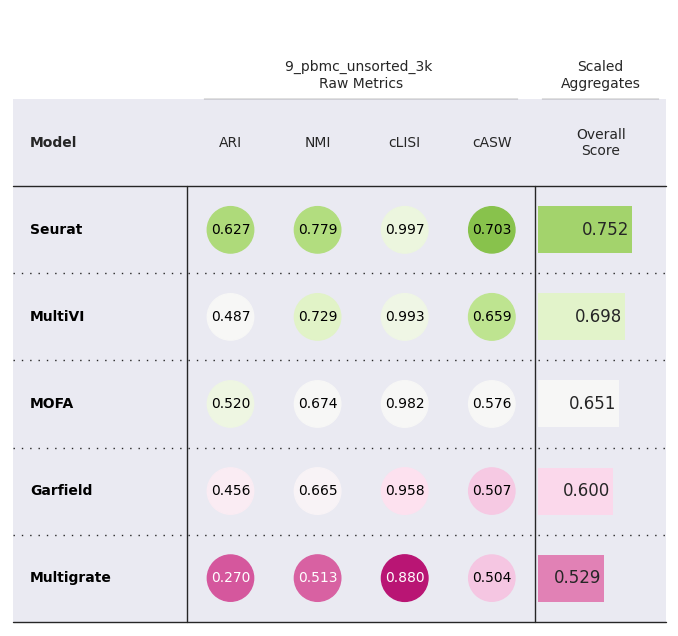

In [5]:
# Plot table
res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/'
benchmarking_folder_path = f"{res_dir}/"

plot_simple_metrics_table(
    df=unrolled_df,
    model_col="model",
    model_col_width=1.6,
    group_col="dataset",
    metric_cols=metric_cols_single_sample, # metric_cols_single_sample, category_cols_single_sample
    metric_col_weights=metric_col_weights_single_sample, # metric_col_weights_single_sample, category_col_weights_single_sample
    metric_col_titles=[col.replace(" ", "\n") for col in metric_col_titles_single_sample], # category_col_titles_single_sample
    metric_col_width=0.8, # 0.8,
    aggregate_col_width=1.2,
    plot_width=8.5, # 32,
    plot_height=8,
    show=True,
    save_dir=benchmarking_folder_path,
    save_name=f"benchmarking_metrics_paired_scRNA-ATAC.svg")

### 多个图合并一起画

In [9]:
## 前5个数据集
datasets = ["1_ShareSeq_Skin", "2_brain_ShareSeq","3_brain_SNARE",
            "4_brain_ISSAAC_seq", "5_human_brain_10x"]
models = ['Garfield', 'Multigrate', 'MultiVI', 'MOFA', 'Seurat']

summary_df = pd.DataFrame()
for dataset in datasets:
    res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/'
    dataset_df = pd.read_csv(f'{res_dir}/{dataset}_metrics_result.csv') # _best_reso
    dataset_df.drop(columns=["Isolated_Labels_ASW"], inplace=True)
    dataset_df.columns = ["ARI", "NMI", "cLISI", "cASW", "model", "dataset"]
            
    # Apply min-max scaling to metric columns
    # for i in range(len(metric_cols_single_sample)):
    #     min_val = dataset_df[metric_cols_single_sample[i]].min()
    #     max_val = dataset_df[metric_cols_single_sample[i]].max()
    #     dataset_df[metric_cols_single_sample[i] + "_scaled"] = ((
    #         dataset_df[metric_cols_single_sample[i]] - min_val) / (max_val - min_val))

    summary_df = pd.concat([summary_df, dataset_df], ignore_index=True)
    continue
    
# cat_0_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[0:2]]
# cat_1_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[2:4]]
# cat_2_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[4:6]]

cat_0_scaled_metric_cols = [metric_col for metric_col in metric_cols_single_sample[0:2]]
cat_1_scaled_metric_cols = [metric_col for metric_col in metric_cols_single_sample[2:4]]
    
summary_df[category_cols_single_sample[0]] = np.average(summary_df[cat_0_scaled_metric_cols],
                                                        weights=metric_col_weights_single_sample[0:2],
                                                        axis=1)
summary_df[category_cols_single_sample[1]] = np.average(summary_df[cat_1_scaled_metric_cols],
                                                        weights=metric_col_weights_single_sample[2:4],
                                                        axis=1)
# summary_df[category_cols_single_sample[2]] = np.average(summary_df[cat_2_scaled_metric_cols],
#                                                         weights=metric_col_weights_single_sample[4:6],
#                                                         axis=1)
summary_df["Overall Score"] = np.average(summary_df[category_cols_single_sample[:2]],
                                         weights=category_col_weights_single_sample[:2],
                                         axis=1)

# Plot over all loss weights combinations
# Prepare metrics table plot
group_cols = ["dataset", "model"]
aggregate_df = summary_df.groupby(group_cols).mean("Overall Score").sort_values("Overall Score", ascending=False)[
    metric_cols_single_sample + ["Overall Score"]].reset_index()

unrolled_df = pd.melt(aggregate_df, 
   id_vars=group_cols,
   value_vars=metric_cols_single_sample + ["Overall Score"],
   var_name="score_type", 
   value_name="score")

# Create spatial indicator column
def is_spatially_aware_model(row):
    if row["model"] in ["Garfield", "STACI", "DeepLinc", "GraphST", "CellCharter"]:
        return True
    return False
unrolled_df["spatially_aware"] = unrolled_df.apply(lambda row: is_spatially_aware_model(row), axis=1)
unrolled_df = unrolled_df[["dataset", "spatially_aware", "model", "score_type", "score"]]

# Order datasets
unrolled_df["dataset"] = pd.Categorical(unrolled_df["dataset"], categories=datasets, ordered=True)
unrolled_df = unrolled_df.sort_values(by="dataset")

# unrolled_df["model"] = unrolled_df["model"].replace("NicheCompass GATv2", "NicheCompass")
#unrolled_df["model"] = unrolled_df["model"].replace("NicheCompass GCN", "Mini NicheCompass")

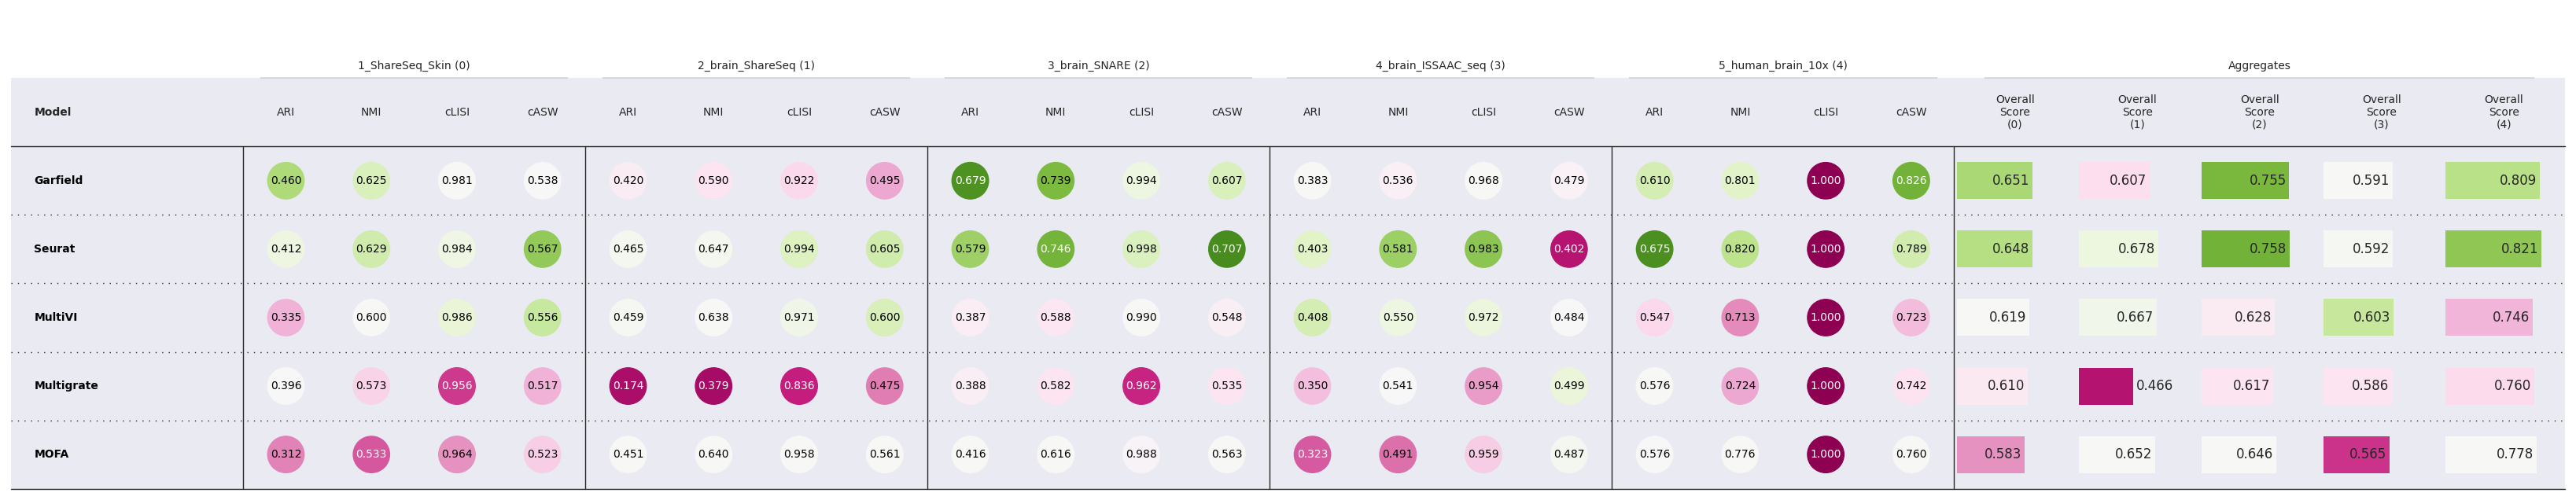

In [10]:
### Supplementary fig. 15b: single sample metric averages ###
res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/'
benchmarking_folder_path = f"{res_dir}/"

plot_metrics_table(
    df=unrolled_df,
    model_col="model",
    model_col_width=1.9,
    group_col="dataset",
    metric_cols=metric_cols_single_sample, # metric_cols_single_sample, category_cols_single_sample
    metric_col_weights=metric_col_weights_single_sample, # metric_col_weights_single_sample, category_col_weights_single_sample
    metric_col_titles=[col.replace(" ", "\n") for col in metric_col_titles_single_sample], # category_col_titles_single_sample
    metric_col_width=0.7, # 0.8,
    aggregate_col_width=1.,
    plot_width=42, # 32,
    plot_height=8,
    show=True,
    save_dir=benchmarking_folder_path,
    save_name=f"benchmarking_metrics_paired_scRNA_ATAC_D1-5.svg")

In [5]:
## 最后四个数据集
datasets = ["6_pbmc_granulocyte_sorted_10x", "7_human_pbmc_10x", 
            "8_pbmc_unsorted_10k", "9_pbmc_unsorted_3k"]
models = ['Garfield', 'Multigrate', 'MultiVI', 'MOFA', 'Seurat']

summary_df = pd.DataFrame()
for dataset in datasets:
    res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/'
    dataset_df = pd.read_csv(f'{res_dir}/{dataset}_metrics_result.csv') # _best_reso
    dataset_df.drop(columns=["Isolated_Labels_ASW"], inplace=True)
    dataset_df.columns = ["ARI", "NMI", "cLISI", "cASW", "model", "dataset"]
            
    # Apply min-max scaling to metric columns
    # for i in range(len(metric_cols_single_sample)):
    #     min_val = dataset_df[metric_cols_single_sample[i]].min()
    #     max_val = dataset_df[metric_cols_single_sample[i]].max()
    #     dataset_df[metric_cols_single_sample[i] + "_scaled"] = ((
    #         dataset_df[metric_cols_single_sample[i]] - min_val) / (max_val - min_val))

    summary_df = pd.concat([summary_df, dataset_df], ignore_index=True)
    continue
    
# cat_0_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[0:3]]
# cat_1_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[3:4]]
# cat_2_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[4:6]]

cat_0_scaled_metric_cols = [metric_col for metric_col in metric_cols_single_sample[0:2]]
cat_1_scaled_metric_cols = [metric_col for metric_col in metric_cols_single_sample[2:4]]
    
summary_df[category_cols_single_sample[0]] = np.average(summary_df[cat_0_scaled_metric_cols],
                                                        weights=metric_col_weights_single_sample[0:2],
                                                        axis=1)
summary_df[category_cols_single_sample[1]] = np.average(summary_df[cat_1_scaled_metric_cols],
                                                        weights=metric_col_weights_single_sample[2:4],
                                                        axis=1)
# summary_df[category_cols_single_sample[2]] = np.average(summary_df[cat_2_scaled_metric_cols],
#                                                         weights=metric_col_weights_single_sample[4:6],
#                                                         axis=1)
summary_df["Overall Score"] = np.average(summary_df[category_cols_single_sample[:2]],
                                         weights=category_col_weights_single_sample[:2],
                                         axis=1)

# Plot over all loss weights combinations
# Prepare metrics table plot
group_cols = ["dataset", "model"]
aggregate_df = summary_df.groupby(group_cols).mean("Overall Score").sort_values("Overall Score", ascending=False)[
    metric_cols_single_sample + ["Overall Score"]].reset_index()

unrolled_df = pd.melt(aggregate_df, 
   id_vars=group_cols,
   value_vars=metric_cols_single_sample + ["Overall Score"],
   var_name="score_type", 
   value_name="score")

# Create spatial indicator column
def is_spatially_aware_model(row):
    if row["model"] in ["Garfield", "STACI", "DeepLinc", "GraphST", "CellCharter"]:
        return True
    return False
unrolled_df["spatially_aware"] = unrolled_df.apply(lambda row: is_spatially_aware_model(row), axis=1)
unrolled_df = unrolled_df[["dataset", "spatially_aware", "model", "score_type", "score"]]

# Order datasets
unrolled_df["dataset"] = pd.Categorical(unrolled_df["dataset"], categories=datasets, ordered=True)
unrolled_df = unrolled_df.sort_values(by="dataset")

# unrolled_df["model"] = unrolled_df["model"].replace("NicheCompass GATv2", "NicheCompass")
#unrolled_df["model"] = unrolled_df["model"].replace("NicheCompass GCN", "Mini NicheCompass")

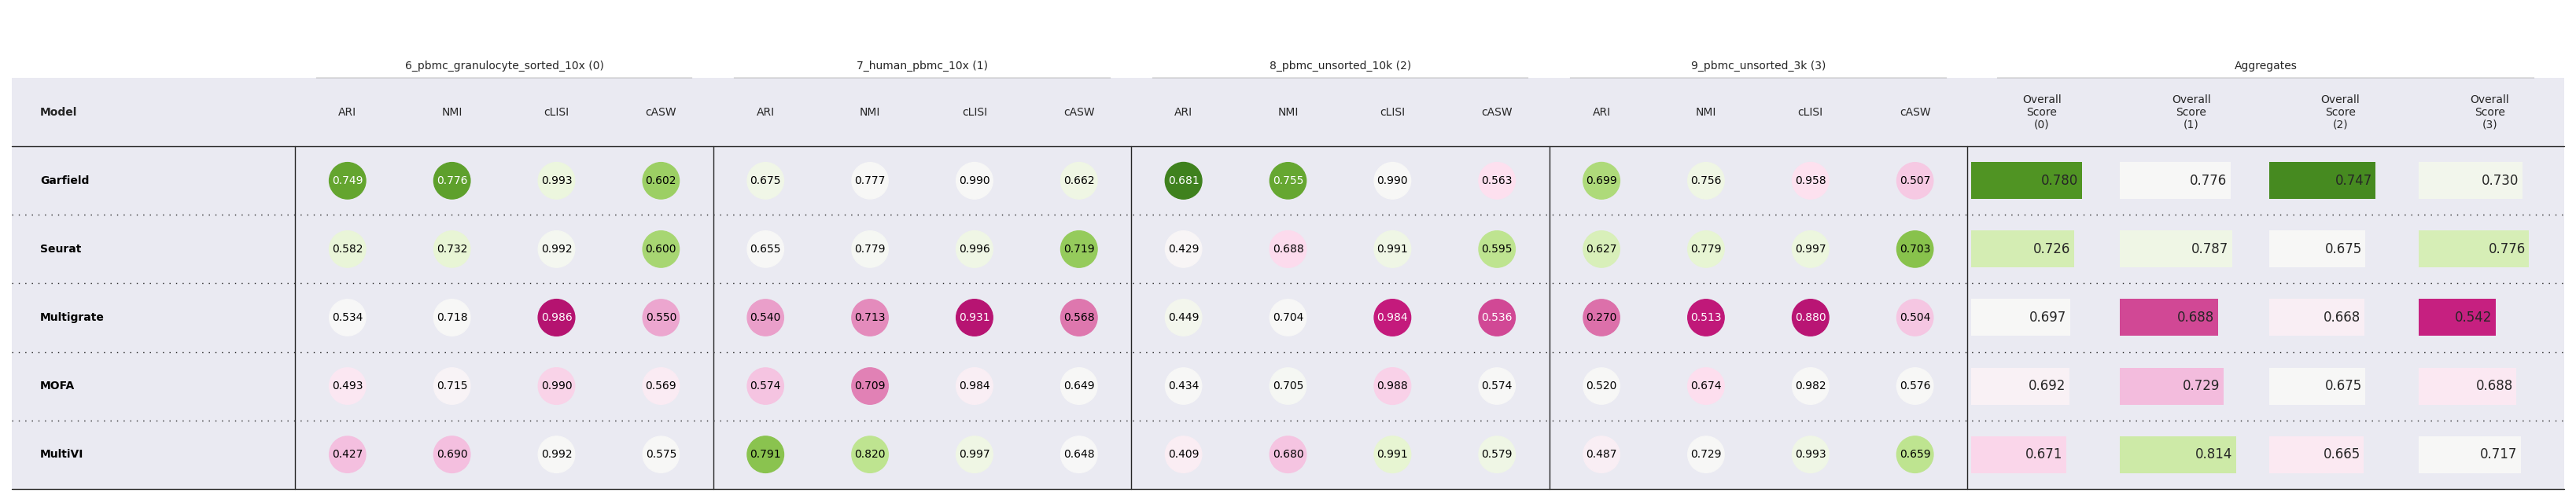

In [6]:
### Supplementary fig. 15b: single sample metric averages ###
res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/'
benchmarking_folder_path = f"{res_dir}/"

plot_metrics_table(
    df=unrolled_df,
    model_col="model",
    model_col_width=1.9,
    group_col="dataset",
    metric_cols=metric_cols_single_sample, # metric_cols_single_sample, category_cols_single_sample
    metric_col_weights=metric_col_weights_single_sample, # metric_col_weights_single_sample, category_col_weights_single_sample
    metric_col_titles=[col.replace(" ", "\n") for col in metric_col_titles_single_sample], # category_col_titles_single_sample
    metric_col_width=0.7, # 0.8,
    aggregate_col_width=1.,
    plot_width=42, # 32,
    plot_height=8,
    show=True,
    save_dir=benchmarking_folder_path,
    save_name=f"benchmarking_metrics_paired_scRNA_ATAC_D6-9.svg")

In [4]:
res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/'
dataset = '2_GSE128639'
dataset_df = pd.read_csv(f'{res_dir}/{dataset}_metrics_result.csv') # _best_reso
dataset_df

,ARI,NMI,cLISI,cASW,model,dataset
0,0.884222,0.860985,0.999245,0.675484,Garfield,2_GSE128639
1,0.488701,0.754594,0.995517,0.566655,Multigrate,2_GSE128639
2,0.588347,0.798205,0.998372,0.568177,TotalVI,2_GSE128639
3,0.568930,0.793671,0.999415,0.598213,scArches,2_GSE128639
4,0.514337,0.800190,0.999907,0.721279,Seurat,2_GSE128639


### paired scRNA + scADT metrics plot

In [7]:
## 最后四个数据集
datasets = ["2_GSE128639","7_zenodo6368128/LUNG", "7_zenodo6368128/PBMC",
            "12_GSE193181/P5", "12_GSE193181/P8"]
models = ['Garfield', 'Multigrate', 'TotalVI', 'scArches', 'Seurat']

summary_df = pd.DataFrame()
for dataset in datasets:
    res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/'
    dataset_df = pd.read_csv(f'{res_dir}/{dataset}_metrics_result.csv') # _best_reso
    # dataset_df.drop(columncs=["Isolated_Labels_ASW"], inplace=True)
    # dataset_df.columns = ["ARI", "NMI", "cLISI", "cASW", "model", "dataset"]
            
    # Apply min-max scaling to metric columns
    # for i in range(len(metric_cols_single_sample)):
    #     min_val = dataset_df[metric_cols_single_sample[i]].min()
    #     max_val = dataset_df[metric_cols_single_sample[i]].max()
    #     dataset_df[metric_cols_single_sample[i] + "_scaled"] = ((
    #         dataset_df[metric_cols_single_sample[i]] - min_val) / (max_val - min_val))

    summary_df = pd.concat([summary_df, dataset_df], ignore_index=True)
    continue
    
# cat_0_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[0:3]]
# cat_1_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[3:4]]
# cat_2_scaled_metric_cols = [metric_col + "_scaled" for metric_col in metric_cols_single_sample[4:6]]

cat_0_scaled_metric_cols = [metric_col for metric_col in metric_cols_single_sample[0:2]]
cat_1_scaled_metric_cols = [metric_col for metric_col in metric_cols_single_sample[2:4]]
    
summary_df[category_cols_single_sample[0]] = np.average(summary_df[cat_0_scaled_metric_cols],
                                                        weights=metric_col_weights_single_sample[0:2],
                                                        axis=1)
summary_df[category_cols_single_sample[1]] = np.average(summary_df[cat_1_scaled_metric_cols],
                                                        weights=metric_col_weights_single_sample[2:4],
                                                        axis=1)
# summary_df[category_cols_single_sample[2]] = np.average(summary_df[cat_2_scaled_metric_cols],
#                                                         weights=metric_col_weights_single_sample[4:6],
#                                                         axis=1)
summary_df["Overall Score"] = np.average(summary_df[category_cols_single_sample[:2]],
                                         weights=category_col_weights_single_sample[:2],
                                         axis=1)

# Plot over all loss weights combinations
# Prepare metrics table plot
group_cols = ["dataset", "model"]
aggregate_df = summary_df.groupby(group_cols).mean("Overall Score").sort_values("Overall Score", ascending=False)[
    metric_cols_single_sample + ["Overall Score"]].reset_index()

unrolled_df = pd.melt(aggregate_df, 
   id_vars=group_cols,
   value_vars=metric_cols_single_sample + ["Overall Score"],
   var_name="score_type", 
   value_name="score")

# Create spatial indicator column
def is_spatially_aware_model(row):
    if row["model"] in ["Garfield", "STACI", "DeepLinc", "GraphST", "CellCharter"]:
        return True
    return False
unrolled_df["spatially_aware"] = unrolled_df.apply(lambda row: is_spatially_aware_model(row), axis=1)
unrolled_df = unrolled_df[["dataset", "spatially_aware", "model", "score_type", "score"]]

# Order datasets
unrolled_df["dataset"] = pd.Categorical(unrolled_df["dataset"], categories=datasets, ordered=True)
unrolled_df = unrolled_df.sort_values(by="dataset")

# unrolled_df["model"] = unrolled_df["model"].replace("NicheCompass GATv2", "NicheCompass")
#unrolled_df["model"] = unrolled_df["model"].replace("NicheCompass GCN", "Mini NicheCompass")

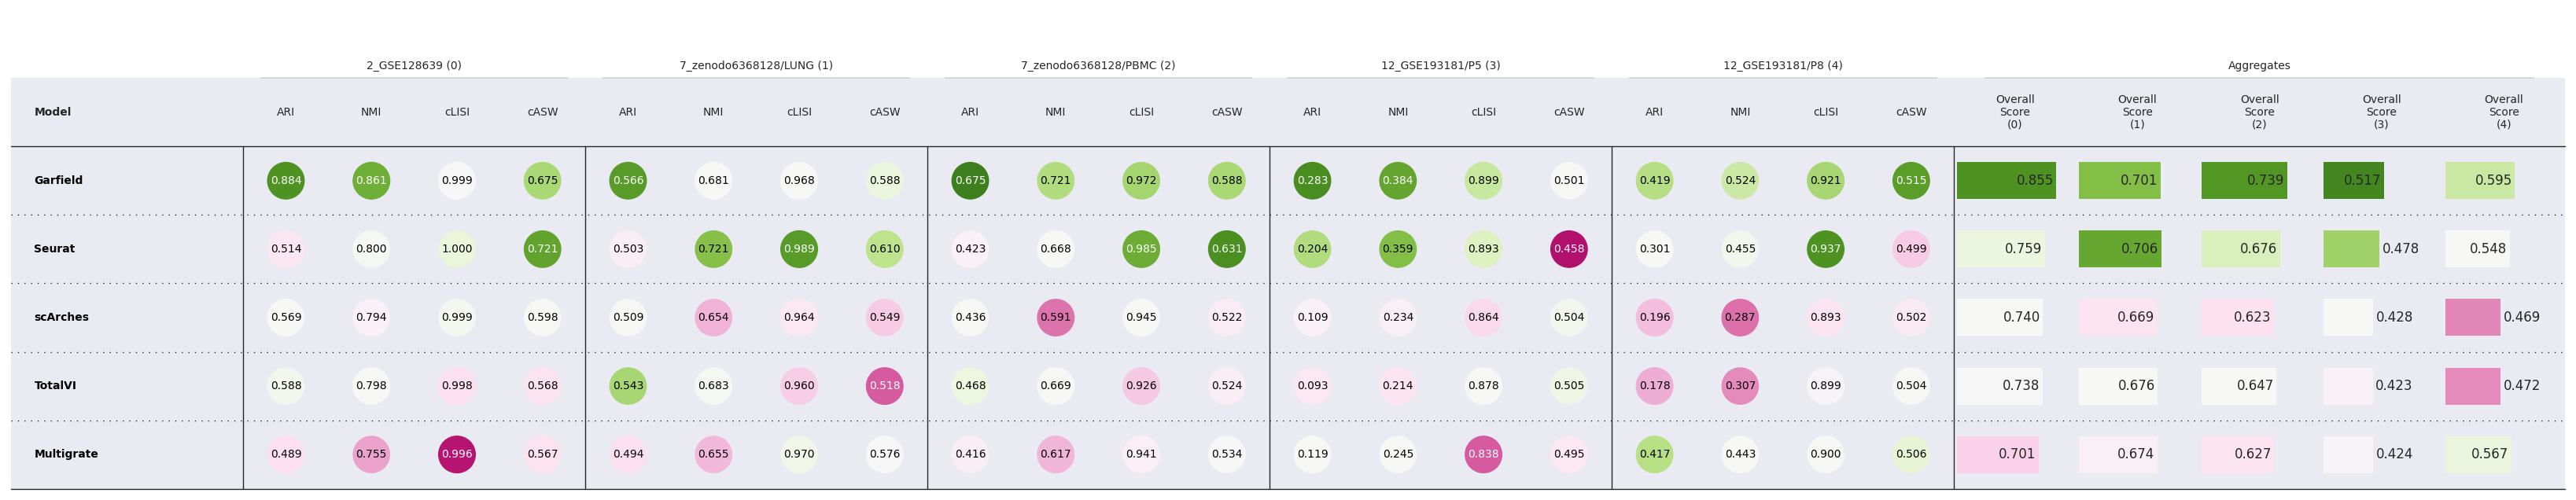

In [8]:
### Supplementary fig. 15b: single sample metric averages ###
res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_Protein/'
benchmarking_folder_path = f"{res_dir}/"

plot_metrics_table(
    df=unrolled_df,
    model_col="model",
    model_col_width=1.9,
    group_col="dataset",
    metric_cols=metric_cols_single_sample, # metric_cols_single_sample, category_cols_single_sample
    metric_col_weights=metric_col_weights_single_sample, # metric_col_weights_single_sample, category_col_weights_single_sample
    metric_col_titles=[col.replace(" ", "\n") for col in metric_col_titles_single_sample], # category_col_titles_single_sample
    metric_col_width=0.7, # 0.8,
    aggregate_col_width=1.,
    plot_width=42, # 32,
    plot_height=8,
    show=True,
    save_dir=benchmarking_folder_path,
    save_name=f"benchmarking_metrics_paired_scRNA_ADT_D1-5.svg")